# Analiza wyników

## Encoder only

W ramach testów zdecydowałem się na sprawdzenie 3 modeli:
- `Voicelab/herbert-base-cased-sentiment` : Został specjalnie dostrojony (tzw. fine-tuning) do zadań analizy wydźwięku w języku polskim, co czyni go naturalnym faworytem
- `tabularisai/multilingual-sentiment-analysis` : jest to model wielojęzyczny, który był trenowany na potężnych, zróżnicowanych korpusach tekstowych w wielu językach jednocześnie. Użycie go w eksperymencie pozwala zweryfikować, czy "ogólny" model globalny radzi sobie z niuansami języka polskiego równie dobrze, co modele trenowane wyłącznie na polskojęzycznych danych.
- `bardsai/twitter-sentiment-pl-base`  : Model polskojęzyczny, trenowany na danych z platformy X. Oznacza to, że jest "ekspertem" od języka potocznego, krótkich form, internetowego slangu i emotikonów. Ewaluacja tego modelu na zbiorze recenzji z PolEmo2.0-IN pozwoli ocenić jak model poradzi sobie w przypadku innej dziedziny tekstów.

Wszystkie modele przyjmują 0.1B parametrów 
Testowane parametry: 
- `max_length`- Na sztywno określa limi tokenów które model może przyjąć do analizy. W ramach eksperymetnów testowałem wartości z zakresu od 64 do 512 tokenów


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import json
import textwrap

encoder_result_path = Path('encoder_only')

In [43]:
results_overview = pd.read_csv(encoder_result_path / 'overview.csv')
cleaned_results = results_overview[['model', 'max_length', 'accuracy','f1_macro', 'recall_macro', 'precision_macro']]
print(results_overview.columns)
print(cleaned_results)


Index(['model', 'param_id', 'batch_size', 'truncation', 'max_length',
       'accuracy', 'f1_macro', 'recall_macro', 'precision_macro', 'timestamp'],
      dtype='str')
                                          model  max_length  accuracy  \
0         Voicelab/herbert-base-cased-sentiment          64  0.688925   
1         Voicelab/herbert-base-cased-sentiment         128  0.745928   
2         Voicelab/herbert-base-cased-sentiment         256  0.762215   
3         Voicelab/herbert-base-cased-sentiment         512  0.758958   
4             bardsai/twitter-sentiment-pl-base          64  0.700326   
5             bardsai/twitter-sentiment-pl-base         128  0.745928   
6             bardsai/twitter-sentiment-pl-base         256  0.754072   
7             bardsai/twitter-sentiment-pl-base         512  0.762215   
8   tabularisai/multilingual-sentiment-analysis          64  0.706840   
9   tabularisai/multilingual-sentiment-analysis         128  0.776873   
10  tabularisai/multilingual

(<Figure size 1000x700 with 5 Axes>,
 array([<Axes: title={'center': 'accuracy'}, xlabel='max_length', ylabel='model'>,
        <Axes: title={'center': 'f1_macro'}, xlabel='max_length', ylabel='model'>,
        <Axes: title={'center': 'recall_macro'}, xlabel='max_length', ylabel='model'>,
        <Axes: title={'center': 'precision_macro'}, xlabel='max_length', ylabel='model'>],
       dtype=object))

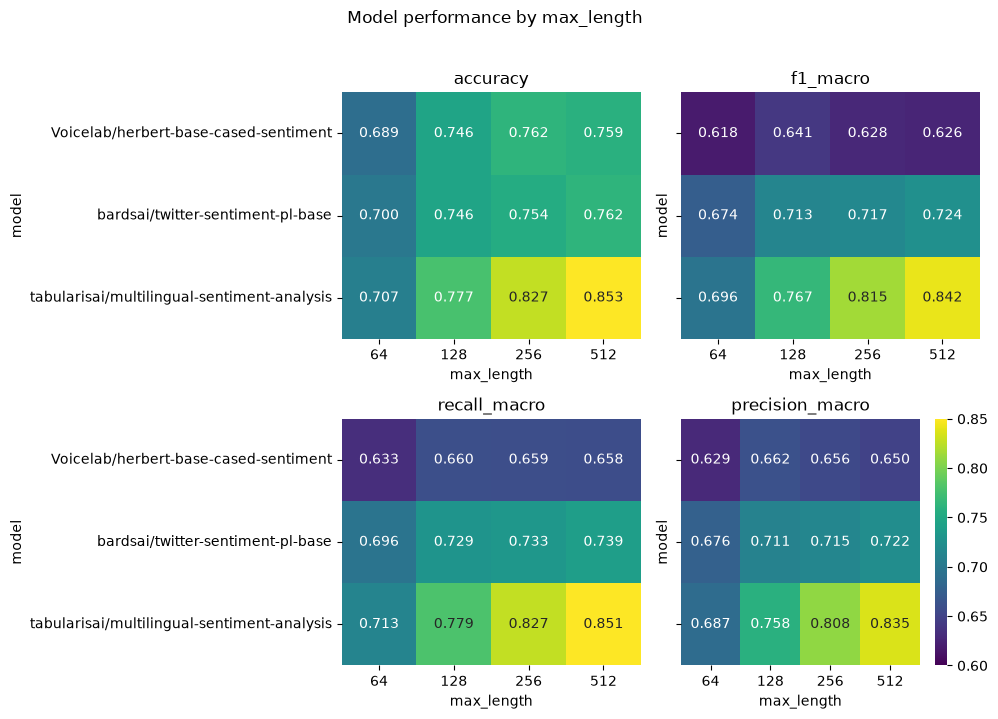

In [44]:
METRIC_COLUMNS = ['accuracy', 'f1_macro', 'recall_macro', 'precision_macro']


def create_heatmap(
    results_overview: pd.DataFrame,
    value_column: str,
    ax=None,
    min_value: float = 0.6,
    max_value: float = 0.85,
    cbar: bool = True,
):
    heatmap_data = results_overview.pivot(
        index='model', columns='max_length', values=value_column
    )
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt='.3f',
        cmap='viridis',
        vmin=min_value,
        vmax=max_value,
        ax=ax,
        cbar=cbar,
    )
    if ax is not None:
        ax.set_title(value_column)
        ax.set_xlabel('max_length')
        ax.set_ylabel('model')
    return heatmap_data


def plot_all_heatmaps(
    results_overview: pd.DataFrame,
    metric_columns: list[str] = METRIC_COLUMNS,
    min_value: float = 0.6,
    max_value: float = 0.85,
    n_cols: int = 2,
):
    n_metrics = len(metric_columns)
    n_rows = (n_metrics + n_cols - 1) // n_cols
    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows), sharey=True
    )
    axes = np.atleast_1d(axes).flatten()

    for i, (ax, metric) in enumerate(zip(axes, metric_columns)):
        create_heatmap(
            results_overview,
            metric,
            ax=ax,
            min_value=min_value,
            max_value=max_value,
            cbar=(i == n_metrics - 1),
        )

    for ax in axes[n_metrics:]:
        ax.set_visible(False)

    fig.suptitle('Model performance by max_length', y=1.02)
    fig.tight_layout()
    return fig, axes


plot_all_heatmaps(cleaned_results)

Od razu jesteśmy w stanie zauważyć, że osiągane wnyniki są znacznie lepsze wraz ze wzrotem maksymalnej dopuszczalnej długości. Co ciekawe spośród wszystkich modeli najgorzej wypadł faworyt `Voicelab/herbert-base-cased-sentiment` osiągając wyraźnie niższe wartości metryk w każdym przypadku. Dużym zaskoczeniem okazały się wyniki `tabularisai/multilingual-sentiment-analysis`, jako że model trenowany jest na wielu, językach spodziewać się można było wyniku, który odstaje od wyspecjalizowanych polskich modeli.

In [45]:
model_names = ["Voicelab_herbert-base-cased-sentiment", "tabularisai_multilingual-sentiment-analysis", "bardsai_twitter-sentiment-pl-base"]
postfix = '_ml512_trunc'
model_names = [model_name + postfix for model_name in model_names]
print(model_names)
metrics_details = encoder_result_path / 'metrics'
details = []
for filename in os.listdir(metrics_details):
    if filename.startswith(tuple(model_names)):
        with open(metrics_details / filename, 'r') as f:
            details.append(json.load(f))


for entry in details:
    print(60*'=')
    print('MODEL_NAME =',entry['model'])
    print('WEIGHTED_AVG')
    print('precision =',entry["detailed_report"]['weighted avg']['precision'])
    print('recall =',entry["detailed_report"]['weighted avg']['recall'])
    print('f1-score =',entry["detailed_report"]['weighted avg']['f1-score'])
    print('MACRO_AVG')
    print('precision =',entry["detailed_report"]['macro avg']['precision'])
    print('recall =',entry["detailed_report"]['macro avg']['recall'])
    print('f1-score =',entry["detailed_report"]['macro avg']['f1-score'])
    print(60*'=')

['Voicelab_herbert-base-cased-sentiment_ml512_trunc', 'tabularisai_multilingual-sentiment-analysis_ml512_trunc', 'bardsai_twitter-sentiment-pl-base_ml512_trunc']
MODEL_NAME = bardsai/twitter-sentiment-pl-base
WEIGHTED_AVG
precision = 0.7818221266949898
recall = 0.762214983713355
f1-score = 0.7642343412625716
MACRO_AVG
precision = 0.7220177659454144
recall = 0.739274299680391
f1-score = 0.7240271948174026
MODEL_NAME = tabularisai/multilingual-sentiment-analysis
WEIGHTED_AVG
precision = 0.8567565895694809
recall = 0.8534201954397395
f1-score = 0.8543578510837581
MACRO_AVG
precision = 0.8354324661897676
recall = 0.8507089244652697
f1-score = 0.841973160151817
MODEL_NAME = Voicelab/herbert-base-cased-sentiment
WEIGHTED_AVG
precision = 0.7429817212751331
recall = 0.758957654723127
f1-score = 0.7294235050256609
MACRO_AVG
precision = 0.649615791241405
recall = 0.6582856812298437
f1-score = 0.6262905839018132


In [46]:
def parse_json_to_df_form(dicts: list[dict])->list[dict]:
    rows = []

    for entry in dicts:
        report = entry["detailed_report"]

        row = {
            "model": entry.get("model"),
            "accuracy": report.get("accuracy"),
        }

        # macro avg / weighted avg
        for avg_name in ["macro avg", "weighted avg"]:
            avg = report.get(avg_name, {})
            prefix = avg_name.replace(" ", "_")

            row[f"{prefix}_precision"] = avg.get("precision")
            row[f"{prefix}_recall"] = avg.get("recall")
            row[f"{prefix}_f1_score"] = avg.get("f1-score")
            row[f"{prefix}_support"] = avg.get("support")

        # klasy, np. __label__meta_minus_m
        for label_name, metrics in report.items():
            if not isinstance(metrics, dict):
                continue

            if label_name in ["macro avg", "weighted avg"]:
                continue

            clean_label = (
                label_name
                .replace("__label__", "")
                .replace("-", "_")
                .replace(" ", "_")
            )

            row[f"{clean_label}_precision"] = metrics.get("precision")
            row[f"{clean_label}_recall"] = metrics.get("recall")
            row[f"{clean_label}_f1_score"] = metrics.get("f1-score")
            row[f"{clean_label}_support"] = metrics.get("support")

        rows.append(row)
    return rows

metrics_details = pd.DataFrame(parse_json_to_df_form(details))
metrics_details.to_csv('metrics_details.csv', index=False)


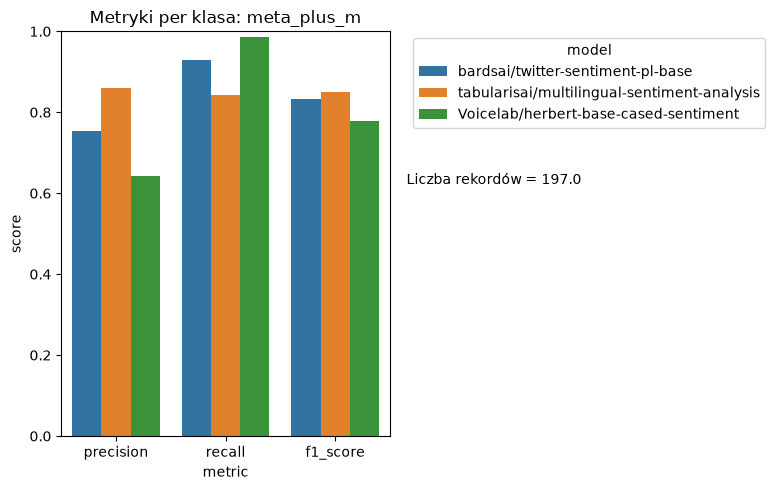

In [47]:
CLASSES = ['meta_plus_m', 'meta_minus_m', 'meta_zero']
METRICS = ['precision', 'recall', 'f1_score']
CT_metric ='support'


def plot_class_metrics_barchart(df: pd.DataFrame, class_index: int):
    class_name = CLASSES[class_index]
    metric_cols = [f'{class_name}_{metric}' for metric in METRICS]

    plot_df = df[['model', *metric_cols]].melt(
        id_vars='model',
        value_vars=metric_cols,
        var_name='metric',
        value_name='score',
    )
    plot_df['metric'] = plot_df['metric'].str.replace(f'{class_name}_', '')

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(data=plot_df, x='metric', y='score', hue='model', ax=ax)
    ax.set_ylim(0, 1)
    ax.set_title(f'Metryki per klasa: {class_name}')
    ax.set_ylabel('score')
    ax.legend(title='model', bbox_to_anchor=(1.05, 1), loc='upper left')
    count = df[f'{class_name}_{CT_metric}'].iloc[0]
    ax.text(
        1.05,
        0.65,
        f'Liczba rekordów = {count}',
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top'
    )
    fig.tight_layout()
    plt.show()


plot_class_metrics_barchart(metrics_details, 0)

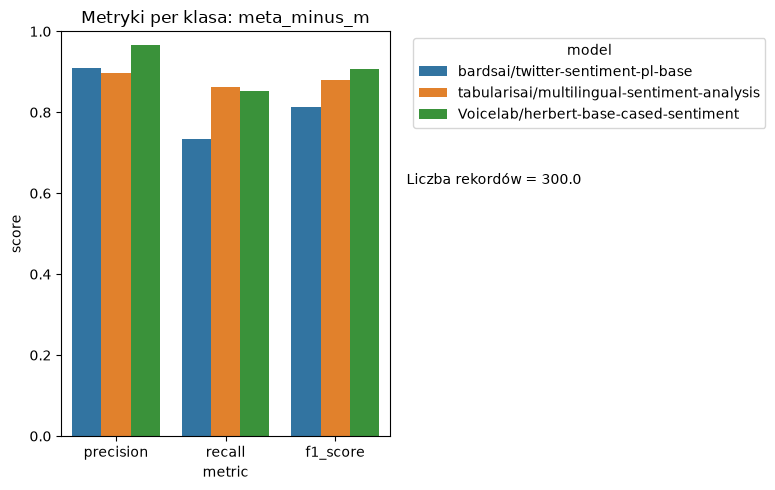

In [48]:
plot_class_metrics_barchart(metrics_details, 1)

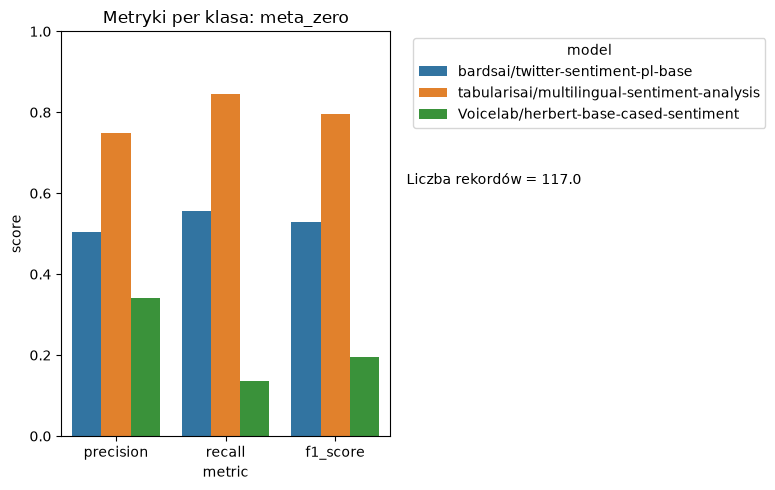

In [49]:
plot_class_metrics_barchart(metrics_details, 2)

Analizując wartości dla każdej zmiennej docelowej od razu jesteśmy w stanie zauważyć czemu model `tabularisai/multilingual-sentiment-analysis` radzi sobie zauważalnie lepiej od pozostałych. Reszta modeli ma ogromne problemy z wykrywaniem tekstów o neutralnym sentymencie. Zarówno dla `bardsai/twitter-sentiment-pl-base`  jak  `Voicelab/herbert-base-cased-sentiment` były trenowane na danych które głównie zawierają negatywne i pozytywne nacechowane rekordy - wypowiedzi na twitterze oraz recenzje z natury mają wydźwięk skrajnie negatywny lub pozytywny. Większość ludzi nie decyduje się na wystawienie opinii lub komentarza pod wpisem o ile nie wzbudza w nich to skrajnych emocji. 

Współczesne modele wielojęzyczne trenowane są na absolutnie gigantycznych, zróżnicowanych danych (artykuły z Wikipedii, newsy, recenzje produktów z Amazona w 100 językach). Dzięki temu model  widział miliony przykładów tekstów czysto informacyjnych/opisowych i zbudował sobie znacznie silniejszą i bardziej uniwersalną reprezentację "neutralności", która świetnie zgeneralizowała się na polskie recenzje.


In [50]:
prefix = 'wyniki_'
model_names = ["Voicelab_herbert-base-cased-sentiment", "tabularisai_multilingual-sentiment-analysis", "bardsai_twitter-sentiment-pl-base"]
postfix = '_ml512_trunc'
file_prefixes = [prefix + model_name + postfix for model_name in model_names]

predictions_path = encoder_result_path / 'predictions'
predictions_dfs = {}
for filename in os.listdir(predictions_path):
    if filename.startswith(tuple(file_prefixes)):
        model_name = filename.removeprefix(prefix).removesuffix('.csv').removesuffix(postfix)
        predictions_dfs[model_name] = pd.read_csv(predictions_path / filename)

list(predictions_dfs.keys())

['bardsai_twitter-sentiment-pl-base',
 'tabularisai_multilingual-sentiment-analysis',
 'Voicelab_herbert-base-cased-sentiment']

(<Figure size 1500x400 with 6 Axes>,
 array([<Axes: title={'center': 'bardsai_twitter-sentiment-pl-base'}, xlabel='mapped_prediction', ylabel='target'>,
        <Axes: title={'center': 'tabularisai_multilingual-sentiment-analysis'}, xlabel='mapped_prediction', ylabel='target'>,
        <Axes: title={'center': 'Voicelab_herbert-base-cased-sentiment'}, xlabel='mapped_prediction', ylabel='target'>],
       dtype=object))

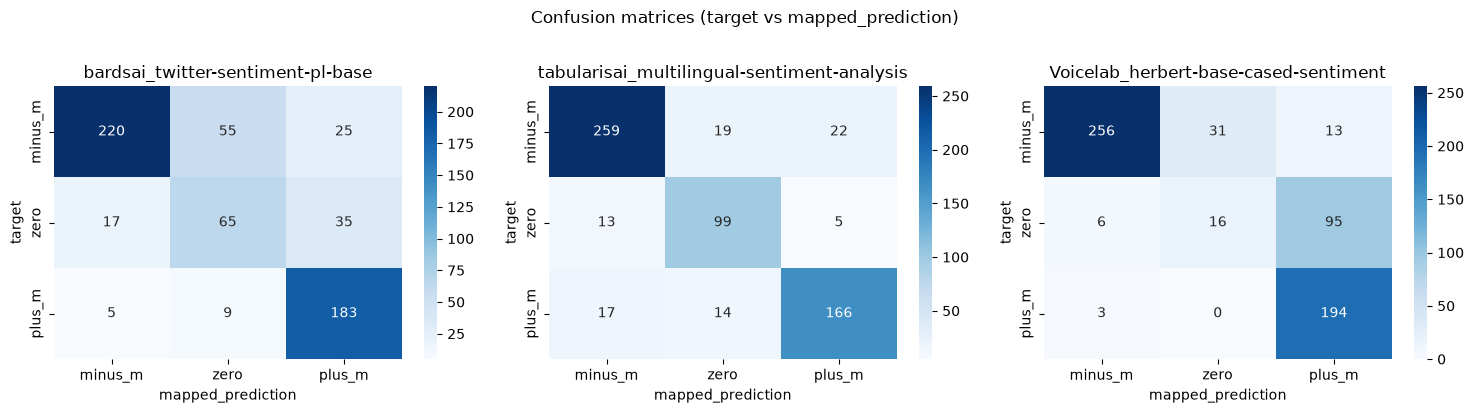

In [51]:
LABELS = [
    '__label__meta_minus_m',
    '__label__meta_zero',
    '__label__meta_plus_m',
]
LABEL_NAMES = ['minus_m', 'zero', 'plus_m']


def confusion_matrix_df(df: pd.DataFrame) -> pd.DataFrame:
    return pd.crosstab(
        df['target'],
        df['mapped_prediction'],
        rownames=['true'],
        colnames=['predicted'],
    ).reindex(index=LABELS, columns=LABELS, fill_value=0)


def plot_confusion_matrices(predictions_dfs: dict[str, pd.DataFrame]):
    n_models = len(predictions_dfs)
    fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))
    axes = np.atleast_1d(axes)

    for ax, (model_name, df) in zip(axes, predictions_dfs.items()):
        cm = confusion_matrix_df(df)
        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=LABEL_NAMES,
            yticklabels=LABEL_NAMES,
            ax=ax,
        )
        ax.set_title(model_name)
        ax.set_xlabel('mapped_prediction')
        ax.set_ylabel('target')

    fig.suptitle('Confusion matrices (target vs mapped_prediction)', y=1.02)
    fig.tight_layout()
    return fig, axes


confusion_matrices = {name: confusion_matrix_df(df) for name, df in predictions_dfs.items()}
plot_confusion_matrices(predictions_dfs)


`bardsai/twitter-sentiment-pl-base`
    Ten model wykazuje silną tendencję do błędnego oznaczania tekstów negatywnych jako neutralne. Z macierzy wynika, że aż 55 próbek klasy `__label__meta_minus_m` zostało sklasyfikowanych jako `__label__meta_zero`. Może to wynikać z faktu, że model trenowany na platformie X (Twitter) oczekuje bardzo ekspresyjnego i dosadnego słownictwa negatywnego. Gdy w recenzjach medycznych lub hotelowych narzekanie jest wyrażone w sposób bardziej powściągliwy, opisowy lub ironiczny , model uznaje taki tekst za pozbawiony ładunku emocjonalnego. Dodatkowo model ten pomylił 35 tekstów neutralnych z pozytywnymi, co wskazuje na gubienie się w opisowych tekstach zawierających nasycenie pozytywnych słów kluczowych.

`Voicelab/herbert-base-cased-sentiment`
    Model HerBERT prezentuje zupełnie inny wzorzec błędów. Z prawdziwie neutralnych tekstów  udało mu się poprawnie zidentyfikować zaledwie 16. Aż 95 tekstów (ogromna większość klasy neutralnej) wrzucił do worka `__label__meta_plus_m`. Oznacza to, że model jest "nadmiernie optymistyczny". Wszelkie suche, obiektywne opisy zdarzeń (np. opis przebiegu leczenia lub podsumowanie statystyk), które nie zawierają jawnie negatywnego słownictwa, są przez niego z automatu traktowane jako pozytywne. Świadczy to o jego problemach z rozpoznaniem czysto informacyjnego charakteru wypowiedzi.

`tabularisai/multilingual-sentiment-analysis`
    Na tym tle doskonale widać, dlaczego model wielojęzyczny osiągnął najwyższe metryki ogólne. Jest on znacznie bardziej zrównoważony. Prawidłowo sklasyfikował aż 99 próbek neutralnych, zaledwie kilkanaście razy myląc je z klasą pozytywną lub negatywną. Pokazuje to, że dzięki ogromnemu i zróżnicowanemu korpusowi treningowemu model ten wykształcił najsolidniejszą semantyczną definicję klasy `zero`, potrafiąc odróżnić suchy fakt od ukrytej opinii.


In [52]:
for key, df in predictions_dfs.items(): 
    print(60*"=")
    print('MODEL=',key)
    min_predict = df['prediction_score'].min()
    mean_predict = df['prediction_score'].mean()
    avg_predict = df['prediction_score'].median()
    min_row = df[df['prediction_score']==min_predict]
    print('ŚREDNIA WARTOŚĆ PREDYKCJI =',mean_predict)
    print('MEDIANA WARTOŚCI PREDYKCJI =',avg_predict)
    print()
    print('POWINNA BYĆ =',min_row['target'].iloc[0])
    print('JEST=',min_row['mapped_prediction'].iloc[0])
    print('NAJNIŻSZA WARTOŚĆ PREDyKCJI =',min_predict)
    print('TEKST: ')
    print(textwrap.fill(min_row['sentence'].iloc[0], width=70))

MODEL= bardsai_twitter-sentiment-pl-base
ŚREDNIA WARTOŚĆ PREDYKCJI = 0.9843574465291897
MEDIANA WARTOŚCI PREDYKCJI = 0.9997220039367676

POWINNA BYĆ = __label__meta_minus_m
JEST= __label__meta_zero
NAJNIŻSZA WARTOŚĆ PREDyKCJI = 0.4724003076553345
TEKST: 
OSTRZEGAM ! ! Organizowała m w hotelu imprezę urodzinową na 40 osób .
Poniewaz impreza była tematyczna , w takim samym klimacie chciała m
aby została poprowadzona . Dj którego zapewnił organizator bladego
pojęcia nie miał jaka imprezę będzie prowadził , był kompletnie
nieprzygotowany , trzykrotnie mylił imię jubilatki , a wszelkie
wcześniejsze ustalenia i zapewnienia menadżera okazały się pustymi
słowami . Zaledwie po 3 godzinach " zabawy " usłyszała m , ze napoi
zimnych nie otrzymamy ponieważ już się skończyły choć umowa zawierała
informację ze mamy je bez limitu . Gdy następnego dnia próbowała m
wyjaśnić cała sytuacje a przede wszystkim poinformować o wszystkim
menadżera otrzymała m informacje , ze nieprawda jest to co mówię ,
napoi 

In [53]:
predictions_cp = predictions_dfs['tabularisai_multilingual-sentiment-analysis'].sort_values(by='prediction_score', inplace=False, ascending=True)
print(predictions_cp.columns)
hardest_encoder = predictions_cp[['sentence', 'target', 'mapped_prediction', 'prediction_score']].iloc[0:20] 
hardest_encoder= hardest_encoder[hardest_encoder['target']!=hardest_encoder['mapped_prediction']]

Index(['sentence', 'target', 'raw_prediction', 'mapped_prediction',
       'prediction_score'],
      dtype='str')


Słabsze modele charakteryzują się znacznie wyższą średnią/medianą oceny predykcji - oscylują przy 0.9 natomiast `tabularisai_multilingual-sentiment-analysis` znacznie ostrzej ocenia swoje predykcje jako że jego wartości są bliższe 0.75. Najprawdopodobniej związane jest w z faktem, że model wielojęzykowy jest w stanie klasyfikować wyniki aż na 5 poziomów, stąd model jest mniej pewny swoich decyzji jako, że granica między `positive` a `very positive` jest mniej wyraźna niż granica pomiędzy `pozytwną` a `neutralną` lub `negatywną`.

```json
    "id2label": {
        "0": "Very Negative",
        "1": "Negative",
        "2": "Neutral",
        "3": "Positive",
        "4": "Very Positive"
    }
```

W przypadku tekstów z którymi modele poradziły sobie najgorzej mamy trzy ciekawe przypadki:

- `bardsai_twitter-sentiment-pl-base` wypowiedź ma mocno ironiczny wydźwięk pondato tekst jest pełen słów o silnym, pozytywnym zabarwieniu: "impreza", "urodzinowa", "zabawa", "jubilatka", "zimne napoje". Modele trenowany na krótkich tweetach, będzie bardzo mocno reagował na tak silnie nacechowane słowa. W tekście jednak pojawiają się negatywnie nacechowane słowa takie jak nieprzygotowany, mylił, czy kpina stąd ostatecznie model zaklasyfikował wypowiedź jako neutralną. Dość niepokojącym wskaźnikiem jest wyoska pewność modelu, która wynosi 0.46 

- `tabularisai_multilingual-sentiment-analysis` recenzja zawiera na początku krytykę lekarzy ze szpitala w Chorzowie, dopiero później przechodzimy do recenzji usług samego lekarza, która jest pozytywna. Dodatkowo tekst posiada silnie nacechowane słwoa jak choroba, ból, zapalenie, więc model przyznał recenzji wydźwięk negatywny.  Lecz ocena klasyfikacji jest niska gdyż zaraz obok w tekście znajdziemy polecać, wysoki poziom i rzetelność stąd 

- `Voicelab_herbert-base-cased-sentiment` ostatni przykład jest to po  raport na temat chorób w polskim społeczeństwie. Ponownie przewijają się negatywnie nacechowane słownictwo takie jak złośliwe, złodziej, choroba co czyni predykcję pozytywną stosunkowo dziwną. Możliwe, że decyzja została podjęta na podstawie informacji o poprawie wskaźników zdrowotnych w czasie („mniej”, „spadek”) lub model nieprzywiązuje znacznej wagi do medycznie słownictwa związanego z chorobami. Jest to idealny przykład najczęściej popełnianego przez model błędu, gdzie neutralny tekst uznawany jest za pozytwny. 



## Decoder only

Dla LLMów ponownie zdecydowałem się na wybór 3 różnych modeli:

1. **Qwen2.5-1.5B-Instruct** – lekki model instruktażowy opracowany przez Alibaba Cloud, posiadający około 1,5 miliarda parametrów. Model został zaprojektowany do wykonywania zadań zgodnych z instrukcjami użytkownika, generowania odpowiedzi w ustrukturyzowanej formie oraz realizacji zadań klasyfikacyjnych przy relatywnie niskich wymaganiach obliczeniowych.

2. **Phi-3-mini-4k-instruct** – niewielki model językowy opracowany przez Microsoft, wyposażony w okno kontekstowe o długości 4 tysięcy tokenów. Model został zoptymalizowany pod kątem efektywności i jakości rozumowania przy zachowaniu niewielkiego rozmiaru, dzięki czemu stanowi interesującą alternatywę dla większych modeli językowych.

3. **Qwen2.5-0.5B-Instruct** – najmniejszy z analizowanych modeli, zawierający około 0,5 miliarda parametrów. Został wybrany w celu zbadania wpływu rozmiaru modelu na jakość klasyfikacji oraz sprawdzenia, jak bardzo redukcja liczby parametrów wpływa na skuteczność działania.

Analizowane parametry:

Analizowane parametry konfiguracji modeli:

* **Temperature** – parametr kontrolujący losowość generowanych odpowiedzi. Niższe wartości prowadzą do bardziej deterministycznych i powtarzalnych wyników, natomiast wyższe zwiększają różnorodność generowanych odpowiedzi.
* **Max New Tokens** – maksymalna liczba tokenów, które model może wygenerować w odpowiedzi. Parametr ten ogranicza długość generowanego tekstu oraz wpływa na czas inferencji.
* **Prompting Strategy** – sposób formułowania zapytania do modelu. W eksperymentach porównano podejście **Zero-Shot**, gdzie model otrzymuje jedynie instrukcję zadania, oraz **Few-Shot**, gdzie dodatkowo prezentowane są przykładowe rozwiązania.
* **Model Size** – liczba parametrów modelu, wpływająca na jego zdolności reprezentacyjne, skuteczność klasyfikacji oraz wymagania obliczeniowe.
* **Inference Time** – czas potrzebny modelowi na wygenerowanie odpowiedzi dla pojedynczego przykładu lub całego zbioru testowego.


In [54]:
decoder_result_path = Path('decoder_only')
results_overview = pd.read_csv(decoder_result_path / 'porownanie_llm.csv')

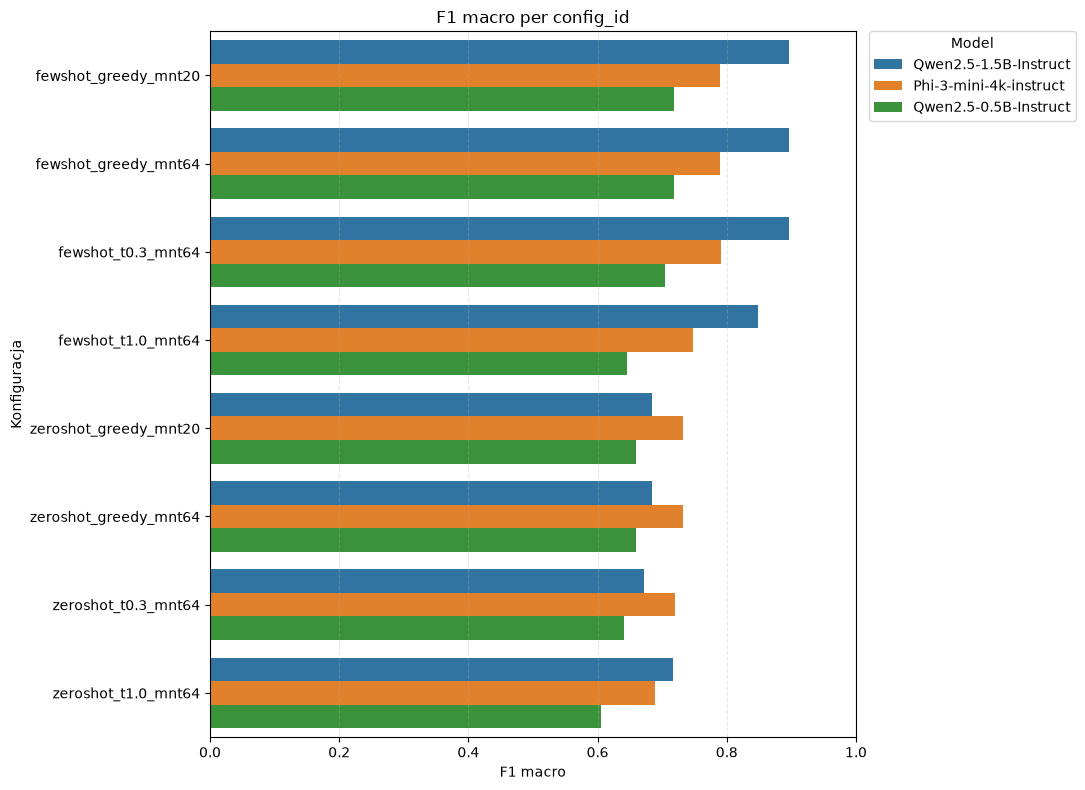

In [55]:
plot_df = results_overview.copy()
plot_df['model_short'] = plot_df['model'].str.split('/').str[-1]
config_order = (
    plot_df.sort_values(['prompt_kind', 'config_id'])['config_id']
    .drop_duplicates()
    .tolist()
)

fig, ax = plt.subplots(figsize=(11, 8))
sns.barplot(
    data=plot_df,
    y='config_id',
    x='f1_macro',
    hue='model_short',
    order=config_order,
    ax=ax,
)
ax.set_xlim(0, 1.0)
ax.set_xlabel('F1 macro')
ax.set_ylabel('Konfiguracja')
ax.set_title('F1 macro per config_id')
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
fig.tight_layout()
plt.show()

### Grupa fewshot

```python
    PROMPT_FEW_SHOT = """Jesteś ekspertem od analizy sentymentu tekstów w języku polskim.
    Określ sentyment poniższego tekstu jako positive, negative lub neutral.

    Przykłady:
    Tekst: "Świetny produkt, polecam wszystkim!"
    Odpowiedź: {{"sentiment": "positive"}}

    Tekst: "Okropna obsługa, nigdy więcej nie wrócę."
    Odpowiedź: {{"sentiment": "negative"}}

    Tekst: "Produkt jest w porządku, nic specjalnego."
    Odpowiedź: {{"sentiment": "neutral"}}

    {format_instructions}

    Tekst do analizy:
    {text}"""

```

Dla konfiguracji fewshot (gdzie promopt uwzględniał przykłady rozwiązancych zadań) liderem okazywał się `Qwen2.5-1.5B`. Możemy zauważyć że na osiągnięte `f1` praktycznie w żadnym stopniu nie przełożyło się `max_new_tokens` konfiguracja z 20 tokenami na odpowiedź osiąga takie same wyniki jak konfiguracja, która na odpowiedź dostała 64 tokeny. Ustawienie temperatury na 0.3 też nie miało znacznego wpływu na osiągane wyniki, dopiero w przypadku `temperature=1` modele osiągały zauważnie gorsze wyniki, co sugeruje, że większa losowość generowania może negatywnie wpływać na stabilność odpowiedzi w zadaniu klasyfikacyjnym.


### Grupa zeroshot

```python
    PROMPT_ZERO_SHOT = """Jesteś ekspertem od analizy sentymentu tekstów w języku polskim.
    Określ sentyment poniższego tekstu jako positive, negative lub neutral.

    {format_instructions}

    Tekst do analizy:
    {text}"""
```
W przypadku konfiguracji **zero-shot** sytuacja wyglądała inaczej. Najlepsze wyniki dla większości ustawień osiągał model `Phi-3-mini`, który uzyskał najwyższe wartości `f1_macro` spośród analizowanych modeli w wariancie bez przykładów w prompcie. Oznacza to, że model ten lepiej radził sobie z samą instrukcją zadania, bez dodatkowego kontekstu w postaci przykładowych odpowiedzi. Co ciekawe, dla konfiguracji z `temperature=1.0` najlepszy wynik ponownie osiągnął `Qwen2.5-1.5B`, jednak tego typu ustawienie wiązało się również z większą niestabilnością generowanych odpowiedzi.


Podsumowując, największy wpływ na jakość klasyfikacji miał sposób konstruowania promptu. Konfiguracje few-shot wyraźnie poprawiały wyniki, szczególnie w przypadku modelu `Qwen2.5-1.5B`, który najlepiej wykorzystywał przykłady zawarte w zapytaniu. Parametry takie jak `max_new_tokens` oraz umiarkowana temperatura `0.3` miały znacznie mniejsze znaczenie. Najbardziej problematyczne okazało się ustawienie `temperature=1.0`, które zwiększało losowość odpowiedzi i w większości przypadków prowadziło do spadku skuteczności klasyfikacji.


In [56]:
failures_df = results_overview.copy()

failures_df = failures_df.sort_values(
    by="n_parse_failed",
    ascending=False
)
(failures_df[['model', 'prompt_kind', 'temperature', 'max_new_tokens', 'n_parse_failed']].iloc[0:5])

,model,prompt_kind,temperature,max_new_tokens,n_parse_failed
10,microsoft/Phi-3-mini-4k-instruct,zeroshot,1.0,64,12
14,microsoft/Phi-3-mini-4k-instruct,fewshot,1.0,64,3
2,Qwen/Qwen2.5-1.5B-Instruct,zeroshot,1.0,64,2
0,Qwen/Qwen2.5-1.5B-Instruct,zeroshot,NaN,64,0
4,Qwen/Qwen2.5-1.5B-Instruct,fewshot,NaN,64,0


Wyraźnie widać, że na największą liczbę porażek w parsowaniu dostajemy w przypadky gdy temperatura ustawiona jest na 1.0. Losowość odpowiedzi modeli jest zwiększana stąd modele częściej zaczynają ignorować podaną instrukcję co uniemożliwia poprawne parsowanie tekstu.  

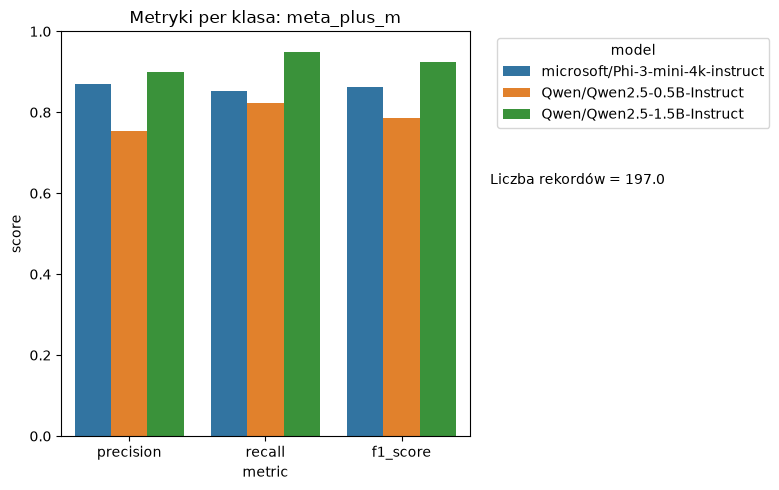

In [57]:
file_names =['microsoft_Phi-3-mini-4k-instruct_fewshot_greedy_mnt64_20260616_104126', 'Qwen_Qwen2.5-0.5B-Instruct_fewshot_greedy_mnt64_20260616_100544', 'Qwen_Qwen2.5-1.5B-Instruct_fewshot_greedy_mnt64_20260616_084655']
postfix = '.json'
file_names = [filename+postfix for filename in file_names]
metrics_details_dec = decoder_result_path / 'metrics'
details = []
for filename in os.listdir(metrics_details_dec):
    if filename in file_names:
        with open(metrics_details_dec / filename, 'r') as f:
            details.append(json.load(f))
metrics_details_df_dec = pd.DataFrame(parse_json_to_df_form(details))
plot_class_metrics_barchart(metrics_details_df_dec, 0)

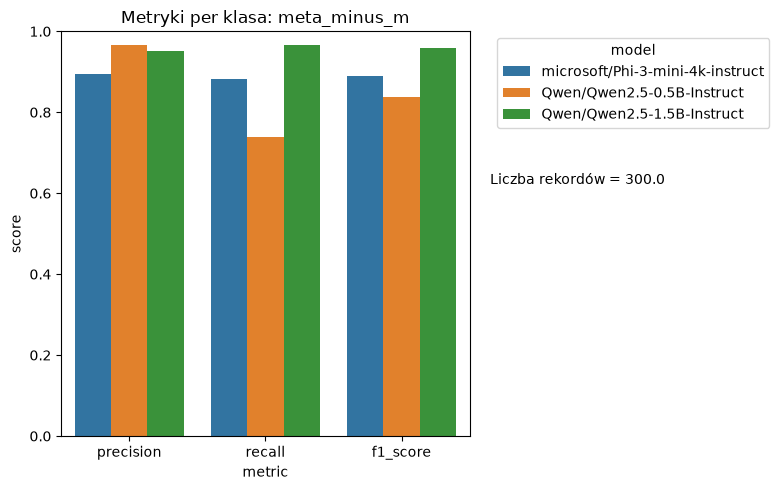

In [58]:
plot_class_metrics_barchart(metrics_details_df_dec, 1)

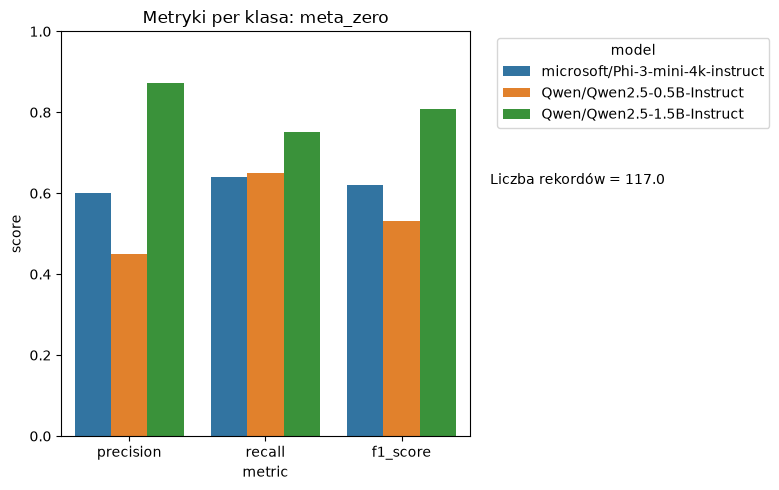

In [59]:
plot_class_metrics_barchart(metrics_details_df_dec, 2)

Podobnie jak dla modeli `encode-only` możemy zauważyć że spadek w wynikach dla neutralnie nacechowanych tekstów. Spadek w wynikach nie jest jednak aż tak znaczny i dotyka wszystkich modeli w porównywalnym stopniu - nie mamy doczynienia z sytuacją gdzie nagle jeden z modeli osiągą f1 na poziomie 0.15

(<Figure size 1500x400 with 6 Axes>,
 array([<Axes: title={'center': 'microsoft_Phi-3-mini-4k-instruct'}, xlabel='mapped_prediction', ylabel='target'>,
        <Axes: title={'center': 'Qwen_Qwen2.5-0.5B-Instruct'}, xlabel='mapped_prediction', ylabel='target'>,
        <Axes: title={'center': 'Qwen_Qwen2.5-1.5B-Instruct'}, xlabel='mapped_prediction', ylabel='target'>],
       dtype=object))

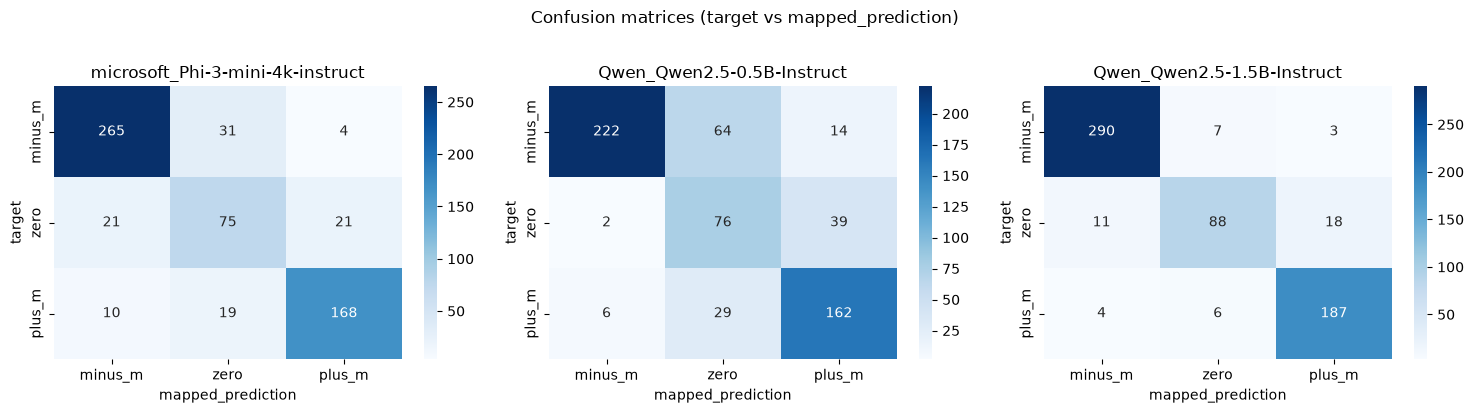

In [60]:
prefix= 'wyniki_'
model_names = ["microsoft_Phi-3-mini-4k-instruct", "Qwen_Qwen2.5-1.5B-Instruct", "Qwen_Qwen2.5-0.5B-Instruct"]
postfix = '_fewshot_greedy_mnt64'
file_prefixes = [prefix + model_name + postfix for model_name in model_names]

predictions_path = decoder_result_path / 'predictions'
predictions_dfs_dec = {}
for filename in os.listdir(predictions_path):
    if filename.startswith(tuple(file_prefixes)):
        model_name = filename.removeprefix(prefix).removesuffix('.csv').removesuffix(postfix)
        predictions_dfs_dec[model_name] = pd.read_csv(predictions_path / filename)

confusion_matrices = {name: confusion_matrix_df(df) for name, df in predictions_dfs_dec.items()}
plot_confusion_matrices(predictions_dfs_dec)


Modele `Qwen2.5-1.5B` oraz `Microsoft Phi3-mini` nie posiadają jednego rodzaju błędu który najcześciej popełniają. Większośc błędów zawiera się na płaszczyźnie dobry-neutralny, zły-neutraly. Modele te rzadko mylą negatywne wypowiedzi z pozytywnymi i wicewersa. Obydwa mają podobny rozkład rodzajów błedów z tym, że `Microsoft Phi3-mini` popełnia dużo więcej błędów. 

Dla `Qwen2.5-1.5B` mamy podobną sytuację jak dla modeluy `bardsai/twitter-sentiment-pl-base`: model za często uznaje odopowiedzi negatywne za neutralne.

In [61]:
comparison_df = pd.concat([metrics_details.iloc[1:2], metrics_details_df_dec.iloc[1:3]])
comparison_df[['model', 'accuracy', 'macro_avg_f1_score', 'weighted_avg_f1_score']]


,model,accuracy,macro_avg_f1_score,weighted_avg_f1_score
1,tabularisai/multilingual-sentiment-analysis,0.853420,0.841973,0.854358
1,Qwen/Qwen2.5-0.5B-Instruct,0.749186,0.718537,0.762907
2,Qwen/Qwen2.5-1.5B-Instruct,0.920195,0.896491,0.918539


Porównując bezpośrednio osiągnięte wyniki dla encoderów i decoderów możemy zauważyć, że `Qwen/Qwen2.5-1.5B-Instruct` zdeklasował pozostałe opcje osiągająć accuracy=92% przy równie imponującym f1. Jednak redukcja jego rozmiaru do 0.5 miliarda parametrów spowodowała drastyczny spadek skuteczności , stawiając go poniżej poziomu modeli Encoder-only. Należy też mieć na uwadzę wielkości testowanych modeli, jako że `tabularisai/multilingual-sentiment-analysis` przyjmuje 0.1B parametrów a pozostałem modele są odopowiednio 5 i 15 większe. Oznacza to, że w scenariuszach o ograniczonym budżecie , wykorzystanie silnego modelu typu Encoder (jak tabularisai) jest rozwiązaniem znacznie bezpieczniejszym i bardziej wydajnym niż poleganie na skompresowanych, najmniejszych wersjach modeli LLM." 

## Porównanie poszególnych wypowiedzi Qwen-1.5B vs tabularisai

### Jak poradził sobie tabularisai vs najtrudniejsze przykłady LLM'a

Jako, że dla LLM nie mamy dokałdnej wartości `prediction_score`, które oceniałoby pewność modelu zdecydowałem się na porównanie wypowiedzi gdzie `Qwen1.5B` wykonał bardziej drastyczny błąd czyli pomylił wypowiedź pozytywną z negatywną i wicewersa.  

In [62]:
df15 = predictions_dfs_dec['Qwen_Qwen2.5-1.5B-Instruct'].copy()
allowed_labels = {
    "__label__meta_minus_m",
    "__label__meta_plus_m"
}
filtered_df = df15[
    df["target"].isin(allowed_labels)
    & df["mapped_prediction"].isin(allowed_labels)
    & df["mapped_prediction"].ne(df["target"])
]
filtered_df = filtered_df[filtered_df['parse_ok']==True]
sentences_hard_llm = filtered_df['sentence']

In [63]:
label_mapping = {
    "__label__meta_minus_m": "negative",
    "__label__meta_plus_m": "positive", 
    "__label__meta_zero": "neutral"
}

df_tabulraisai = predictions_dfs[
    "tabularisai_multilingual-sentiment-analysis"
].copy()

df_tabulraisai["target"] = (
    df_tabulraisai["target"]
    .astype(str)
    .str.strip()
    .map(label_mapping)
)

df_tabulraisai["mapped_prediction"] = (
    df_tabulraisai["mapped_prediction"]
    .astype(str)
    .str.strip()
    .map(label_mapping)
)


compare_df = df_tabulraisai[
    df_tabulraisai["sentence"].isin(sentences_hard_llm)
]
compare_df['guessed']=compare_df['target']==compare_df['mapped_prediction']
compare_df = compare_df[compare_df["guessed"] == True]
compare_df = compare_df.sort_values(
    by="prediction_score",
    ascending=False
)
compare_df[
    ["sentence", "target", "mapped_prediction", "prediction_score", 'guessed']
]

,sentence,target,mapped_prediction,prediction_score,guessed
23,Niniejszą opinię wystawiam Panu Doktorowi po 3...,negative,negative,0.835454,True
82,W 2012r . dr Bieniek zrobił mi korektę powiek ...,negative,negative,0.774785,True
423,"Na zakończenie naszego urlopu , po wybornej Sz...",negative,negative,0.752351,True
506,"Wyspa Vis rewelacyjna , mała ale jest co zwied...",negative,negative,0.653852,True
55,Do Pani Pauliny chodzili śmy na terapię małżeń...,negative,negative,0.646318,True
225,"ja na prawdę nie rozumiem osób , które piszą o...",positive,positive,0.599637,True
252,"Pani doktor jest bardzo miła , ale albo ma pro...",negative,negative,0.498899,True
222,"Jeśli chodzi o kompetencje , jest ok ! ! ! Pan...",negative,negative,0.480693,True
172,"Dr Wilczek to człowiek , który braki wiedzy i ...",negative,negative,0.417412,True
216,Lekarz przygotowany do wizyty ( zapoznał się z...,negative,negative,0.396150,True


In [64]:
encoder_pass = compare_df[
    ["sentence", "target", "mapped_prediction", "prediction_score"]
].iloc[:3]

for row in encoder_pass.itertuples(index=False):
    print("=" * 60)
    print(f"Target: {row.target}")
    print(f"Predykcja: {row.mapped_prediction}")
    print(f"Score: {row.prediction_score:.4f}")
    print(textwrap.fill(str(row.sentence), width=80))

Target: negative
Predykcja: negative
Score: 0.8355
Niniejszą opinię wystawiam Panu Doktorowi po 3 wizycie , dlatego uważam , że
jest ona jak najbardziej wiarygodna . Pan Wojciech Zientala jest lekarzem z
powołania , nie przypadku . Wyróżnia go niebywała , wrodzona , nie wystudiowana
empatia . Pozostałe cechy , takie jak szczery uśmiech , przyjazne i indywidualne
podejście do pacjenta oraz umięjetność słuchania i zadawania właściwych pytań
przekonały mnie , że nie ma sytuacji bez wyjścia : ) Doktor Zientala jest po
prostu fenomenem w środowisku lekarskim ! EDIT : Z perspektywy czasu wiem , że
te wszystkie wizyty to był stracony czas . Rok 2015 i 2016 to był najtrudniejszy
okres w moim życiu , gorzej być już nie mogło ( próby samobójcze ) . Została m
źle zdiagnozowana , to nie było zwykłe przepracowani . . Nie wiem jak to możliwe
, ale Dr Zientala nie zauważył u mnie dużych wahań nastroju od depresji i myśli
samobójczych do euforii . " Bycie na haju " jak to Pan sam określił , oznaczało


Wszystkie trzy teksty stosują zabieg drastycznej zmiany tonu wypowiedzi. Zaczynają się od bardzo silnych, pozytywnych fundamentów, by nagle przejść do krytyki. Mniejsze modele LLM mają ograniczoną zdolność do logicznego wnioskowania na poziomie makro. Kiedy Qwen czyta pierwsze 3-4 zdania naszpikowane słowami z klasy plus, jego mechanizm uwagi kotwiczy się na pozytywnym sentymencie. Kiedy dochodzi do słów takich jak "EDIT:" czy "jednak", model 1.5B często nie rozumie, że te zwroty logicznie unieważniają cały poprzedni tekst. Zamiast tego, próbuje matematycznie uśrednić emocje z całego tekstu, przez co silny negatywny finał miesza się z długim pozytywnym wstępem, dając w efekcie błędną klasyfikację. 

### Jak poradził sobie Qwen z najtrudniejszymi przykładami tabularisai

In [65]:
dfqwen = predictions_dfs_dec['Qwen_Qwen2.5-1.5B-Instruct'].copy()
dfqwen["mapped_prediction"] = (
    dfqwen["mapped_prediction"]
    .astype(str)
    .str.strip()
    .map(label_mapping)
)
dfqwen["target"] = (
    dfqwen["target"]
    .astype(str)
    .str.strip()
    .map(label_mapping)
)
dfqwen = dfqwen[dfqwen['sentence'].isin(hardest_encoder['sentence'])]
dfqwen['guessed'] = dfqwen['mapped_prediction'] == dfqwen['target']
dfqwen[['sentence', 'target', 'mapped_prediction', 'parse_ok', 'guessed']]

,sentence,target,mapped_prediction,parse_ok,guessed
64,Powyższa ( negatywna ) opinia może zniechęcać ...,positive,positive,True,True
114,O dr . Neicu mam jak najlepsze zdanie . W maju...,positive,positive,True,True
124,Przestrzegam wszystkich przed tą dentystką ! D...,negative,negative,True,True
126,"Po wszystkich opiniach , które czytała m i sły...",positive,positive,True,True
149,to co Pani Doktor zrobiła z moją twarzą było n...,positive,positive,True,True
221,""" Dziś dla naszego układu nerwowego cukier jes...",neutral,neutral,True,True
265,Zgłosił em się do Dr Justyna Bogusza w marcu b...,positive,positive,True,True
310,Uwaga ! Ostrzegam przed nieuczciwym hotelem . ...,negative,negative,True,True
325,Publikuję najnowsze zdjęcia pokoju hotelowego ...,negative,negative,True,True
346,"Hotel bardzo zaniedbany , kiedys robil wrazeni...",negative,negative,True,True


In [66]:
encoder_pass = dfqwen[
    ["sentence", "target", "mapped_prediction"]
].iloc[:3]

for row in encoder_pass.itertuples(index=False):
    print("=" * 60)
    print(f"Target: {row.target}")
    print(f"Predykcja: {row.mapped_prediction}")
    print(textwrap.fill(str(row.sentence), width=80))

Target: positive
Predykcja: positive
Powyższa ( negatywna ) opinia może zniechęcać jednakże warte zauważenia jest to
iż lekarz rzeczowo odniósł się do postawionego zarzutu co z pewnością pozwala na
poznanie sytuacji z obu stron . Logiczne wydaje się , iż skierowanie do szpitala
powinno mieć podstawy ( skierowań nie wydaję się " ot tak " ) a podstawy biorą
się z oceny sytuacji - zatem taka ocena i rozpoznanie musiało się odbyć .
Osobiście po dzisiejszej ( pierwszej ) wizycie uważam , iż lekarz przeprowadził
ze mną rozmowę w sposób konkretny i fachowy zadając istotne pytania . Po
zapoznaniu się z problemem wyjaśnił w jaki sposób należy dalej postępować ,
pytając wielokrotnie czy wszystkie kwestie są zrozumiałe . Na koniec mocno
podkreślił , iż w każdej chwili mogę zadzwonić ( na komórkę ) jeśli mój problem
zdrowotny będzie niepokojący . Z czystym sumieniem mogę polecić tego lekarza .
Target: positive
Predykcja: positive
O dr . Neicu mam jak najlepsze zdanie . W maju 2008r . zostalem przy

Możemy zauważyć, że teksty, z którymi encodery miały największy problem, charakteryzują się niezwykle skomplikowaną, wielowątkową strukturą. Autorzy nie formułują swoich opinii w sposób liniowy; zamiast tego nieustannie porównują ocenianą osobę lub usługę z innymi, wcześniejszymi doświadczeniami. Powoduje to, że w tekście notorycznie miesza się słownictwo o skrajnie pozytywnym i negatywnym nacechowaniu. 
Te przykłady udowadniają, że największą przewagą modeli LLM (Decoder-only) nad klasycznymi Encoderami nie jest sama znajomość słów, ale zdolność do śledzenia podmiotu i relacji w zdaniach złożonych. Encodery działają jak świetne agregatory "nastroju" poszczególnych fraz, przez co kapitulują, gdy pacjent pisze o złej chorobie i dobrym lekarzu, bądź o złym lekarzu i nowym, dobrym specjaliście. Modele generatywne o odpowiedniej skali (1.5B) potrafią bezbłędnie wskazać, kto i co jest realnym obiektem końcowej oceny.

# Wnioski Końcowe
Przeprowadzone eksperymenty dobitnie pokazują, że architektura generatywna modeli LLM, choć potężna, nie zawsze stanowi optymalne rozwiązanie dla zadań klasyfikacji. Próba forsowania modelu generatywnego w sztywne ramy klasyfikatora ujawniła jego podatność na "efekt zakotwiczenia", gdzie dedykowane, obustronne modele typu Encoder radziły sobie bezbłędnie dzięki globalnej analizie tekstu. Nie oznacza to jednak, że model Encode-only kompletnie deklasują modele LLM, jako że dla skoplikowanych i wielowątkowych struktur modele Decode-only radzą sobie nieporównyalnie lepiej. Ostatecznie, dla wysoce ustrukturyzowanych zadań, mniejsze modele Encoder-only osiągają porównywalną skuteczność znacznie szybciej i nieporównywalnie taniej w utrzymaniu, wolnym od błędów formatowania/halucynajcji.